<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_14_2_bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 14: Wrapping Up**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 14 Material

* Part 14.1: Model Drift [[Notebook]](t81_558_class_14_1_drift.ipynb)
* **Part 14.2: Dealing with Bias** [[Notebook]](t81_558_class_14_2_bias.ipynb)
* Part 14.3: Other Deep Learning Frameworks [[Notebook]](t81_558_class_14_3_frameworks.ipynb)
* Part 14.4: Deploying a PyTorch Neural Network [[Notebook]](t81_558_class_14_4_deploy.ipynb)
* Part 14.5: The Future of AI [[Notebook]](t81_558_class_14_5_new_tech.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 14.2: Dealing with Bias

Machine learning models are increasingly used to make or inform decisions that affect people's lives: who gets a loan, which resumes are reviewed, how medical resources are allocated. When those decisions systematically disadvantage a group of people, the model is exhibiting **bias** in the fairness sense of the word. Unlike the statistical bias of the bias-variance tradeoff, this is bias in the everyday, ethical sense, and it is one of the most serious risks in deploying machine learning in the real world.

A model does not need any malicious intent, or even access to a protected attribute like race or gender, to be biased. Models learn the patterns in their training data, and if that data reflects historical discrimination or unequal representation, the model will faithfully reproduce and even amplify those patterns. Worse, a model can discriminate through *proxy* features, seemingly neutral inputs like a zip code or a school name that happen to correlate with a protected group.

This section explains where bias comes from, introduces the metrics used to measure fairness, and demonstrates on a simulated hiring dataset how a model can produce unfair outcomes even without seeing the protected attribute directly, along with one straightforward technique for mitigating it.

## Where Bias Comes From

Bias enters a model through its data far more often than through its algorithm. Several distinct sources are worth naming.

* **Historical bias.** The training labels encode past human decisions that were themselves unfair. A model trained on decades of hiring decisions learns to imitate whatever bias those decisions contained.
* **Representation bias.** Some groups are underrepresented in the training data, so the model learns their patterns poorly and performs worse for them.
* **Proxy features.** Even when a protected attribute is deliberately excluded, other features correlated with it let the model reconstruct and act on group membership indirectly.
* **Feedback loops.** A biased model shapes the future data it is trained on, as when a policing model sends patrols to over-policed areas, generating more recorded incidents there, which further biases the next model.

Because these sources live in the data and the deployment context, simply deleting the protected attribute from the feature set is not enough to make a model fair, as the demonstration will show.

## Measuring Fairness

You cannot manage what you do not measure, so fairness work begins with metrics that compare a model's behavior across groups. Several standard definitions exist, and importantly, they can conflict with one another.

* **Demographic parity** asks whether the positive-prediction rate is equal across groups: does each group get approved at the same rate?
* **Disparate impact** expresses this as a ratio of selection rates between groups. A common legal rule of thumb, the "four-fifths rule," treats a ratio below 0.8 as evidence of adverse impact.
* **Equalized odds** asks whether the model is equally *accurate* across groups, requiring equal true-positive and false-positive rates rather than equal selection rates.

These definitions embody genuinely different notions of fairness, and it is mathematically impossible to satisfy all of them at once except in trivial cases. Choosing which to prioritize is an ethical and contextual decision, not a purely technical one. We will use selection rate and disparate impact in the demonstration because they are the most intuitive.

## Demonstrating Bias

We simulate a hiring model. Two groups of candidates, which we will call group A and group B, are equally qualified on average. However, the *historical* hiring labels in our training data favor group A, encoding a past bias. Crucially, we do **not** give the model the group attribute. We give it a genuine qualification score and one seemingly neutral feature that happens to correlate with group, a proxy. We then check whether the model, trained only on qualification and the proxy, still discriminates.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

n = 5000
group = np.random.randint(0, 2, n)              # 0 = group A, 1 = group B
qualification = np.random.randn(n)              # true merit, same for both groups

# Historical labels are BIASED: group A received a hiring boost in the past.
logit = 2.0 * qualification + 1.3 * (group == 0) - 0.7
hired = (np.random.rand(n) < 1 / (1 + np.exp(-logit))).astype(np.int64)

# The model never sees `group`. It sees qualification and a NEUTRAL-looking proxy
# feature that happens to correlate with group membership.
proxy = 0.9 * group + 0.5 * np.random.randn(n)
X = np.stack([qualification, proxy], axis=1).astype(np.float32)

Xt, yt = torch.tensor(X), torch.tensor(hired)
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
for _ in range(400):
    opt.zero_grad()
    loss_fn(model(Xt), yt).backward()
    opt.step()

with torch.no_grad():
    prob_hire = torch.softmax(model(Xt), dim=1)[:, 1].numpy()
predicted_hire = (prob_hire >= 0.5).astype(int)

rate_A = predicted_hire[group == 0].mean()
rate_B = predicted_hire[group == 1].mean()
print(f"Selection rate, group A: {rate_A:.1%}")
print(f"Selection rate, group B: {rate_B:.1%}")
print(f"Disparate impact ratio (B / A): {rate_B / rate_A:.2f}   "
      f"({'FAILS' if rate_B / rate_A < 0.8 else 'passes'} the 0.8 rule)")

Selection rate, group A: 54.4%
Selection rate, group B: 41.2%
Disparate impact ratio (B / A): 0.76   (FAILS the 0.8 rule)


Although the two groups are equally qualified and the model was never shown the group attribute, it selects group B at a substantially lower rate than group A, failing the four-fifths rule. The model reconstructed group membership from the proxy feature and reproduced the historical bias baked into the training labels. This is the central lesson: *fairness is not achieved by hiding the protected attribute*, because bias flows through proxies and through the labels themselves.

## Mitigating Bias

Mitigation techniques fall into three stages of the pipeline. **Pre-processing** methods alter the training data, for example by reweighting or resampling so that groups are balanced and the biased label pattern is weakened. **In-processing** methods change the training objective, adding a fairness constraint or penalty so the model is optimized for accuracy and fairness together. **Post-processing** methods adjust the trained model's outputs, most simply by choosing different decision thresholds for different groups so that selection rates are equalized.

We apply the post-processing approach because it is simple and transparent. Instead of a single 0.5 threshold, we choose a group-specific threshold that brings the two selection rates into balance, targeting demographic parity. The bar chart compares selection rates before and after the adjustment.

Group thresholds -> A: 0.59, B: 0.43
Before mitigation: disparate impact 0.76
After  mitigation: disparate impact 0.99


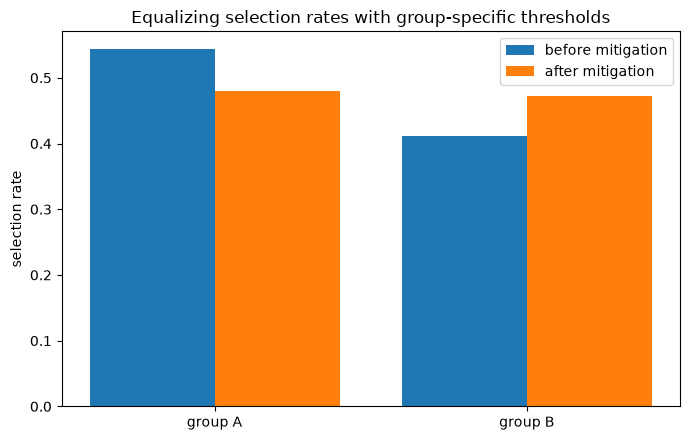

In [3]:
# Post-processing: pick a group-specific threshold so selection rates match.
target_rate = predicted_hire.mean()            # overall selection rate as the target


def rate_at(threshold, mask):
    return (prob_hire[mask] >= threshold).mean()


def threshold_for_group(mask, target):
    # Find the threshold whose selection rate for this group is closest to target.
    candidates = np.linspace(0.01, 0.99, 99)
    rates = [rate_at(t, mask) for t in candidates]
    return candidates[int(np.argmin(np.abs(np.array(rates) - target)))]


thr_A = threshold_for_group(group == 0, target_rate)
thr_B = threshold_for_group(group == 1, target_rate)

fair_hire = np.where(group == 0, prob_hire >= thr_A, prob_hire >= thr_B).astype(int)
fair_A = fair_hire[group == 0].mean()
fair_B = fair_hire[group == 1].mean()

print(f"Group thresholds -> A: {thr_A:.2f}, B: {thr_B:.2f}")
print(f"Before mitigation: disparate impact {rate_B / rate_A:.2f}")
print(f"After  mitigation: disparate impact {fair_B / fair_A:.2f}")

labels = ["group A", "group B"]
x = np.arange(2)
plt.figure(figsize=(7, 4.5))
plt.bar(x - 0.2, [rate_A, rate_B], width=0.4, label="before mitigation")
plt.bar(x + 0.2, [fair_A, fair_B], width=0.4, label="after mitigation")
plt.xticks(x, labels)
plt.ylabel("selection rate")
plt.title("Equalizing selection rates with group-specific thresholds")
plt.legend()
plt.tight_layout()
plt.show()

After the adjustment the two groups are selected at nearly equal rates, and the disparate impact ratio moves close to 1.0. The mitigation worked, but it is worth being clear-eyed about the tradeoffs. Group-specific thresholds raise their own legal and ethical questions, they can reduce overall accuracy, and equalizing selection rates (demographic parity) may violate a different fairness definition such as equalized odds. There is no purely technical solution to fairness; these tools inform a decision that is ultimately about values and context.

The responsible path is to measure fairness explicitly, involve domain and ethics expertise, document the tradeoffs, and monitor deployed models for biased outcomes just as we monitor them for drift. With models understood, evaluated, and made fairer, the remaining sections of this module widen the lens: first to the broader landscape of tools in [Other Deep Learning Frameworks](t81_558_class_14_3_frameworks.ipynb).